[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BartekDaniluk/Big_Data/blob/main/Pytorch_intro.ipynb)


# Pytorch

In [ ]:
import torch

A Tensor is essentially a multidimensional array, the fundamental data structure in deep learning. Similar to NumPy arrays, there are many methods for constructing a tensor in PyTorch.

In [ ]:
data = [[1,2,3], [4,5,6]]
new_tensor = torch.tensor(data)

In [ ]:
print(new_tensor)

tensor([[1, 2, 3],
        [4, 5, 6]])


Just like in NumPy, you can create a tensor of a desired shape initialized with ones, zeros, or random values.

In [ ]:
shape = (2,2)

ones = torch.ones(shape)
zeros = torch.zeros(shape)
random_t = torch.randn(shape)

In [ ]:
print(f'{ones}\n{zeros}\n{random_t}')

tensor([[1., 1.],
        [1., 1.]])
tensor([[0., 0.],
        [0., 0.]])
tensor([[-0.1728, -1.1229],
        [ 0.4208,  0.1510]])


Or you can mimic another tensor's properties (like its shape and device).

In [ ]:
rand_like = torch.randn_like(new_tensor, dtype=torch.float)
rand_like

tensor([[ 1.3400, -0.8129, -0.4565],
        [-0.5526,  1.0252,  0.1279]])

Every tensor has 3 attributes:

* .shape - Tuple that describes the dimensions of the tensor. For example torch.size([1,2]) tells us that it's a tensor with 1 row and 2 columns. Shape is the most important part in pytorch. 99% of errors are shape mismatches.

*  .device - Tells us where the tensor's data is loaded. CPU or GPU. By default it's CPU

* .dtype - the data type of the tensor. torch.float32 by default, so the standard single precision you'll see all across AI world, The model parameters use this dtype in training (it might change later on in the model's lifetime, through quantization and such). It's because the changes in the gradient are tiny nudges, like 0.0013.

In [ ]:
print(f'Shape: {rand_like.shape}')
print(f'dtype: {rand_like.dtype}')
print(f'device: {rand_like.device}')

Shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu


Model params must be a float type. float32 is the standard. Stuff that learns has to be a float.

# Autograd

Automatic differentiation. So a pytorch built in gradient calculator.

 You turn it on by setting requires_grad = true, that allows the tensor to learn, otherwise it's just a data tensor. This makes the tensor a learnable parameter now, just like model weights and bias.

In [ ]:
data_tensor = torch.tensor([[1,2,3,4], [5,6,7,8]])

w = torch.tensor([[1.0], [2.0]], requires_grad=True)

In [ ]:
print(f'Data tensor requires_grad {data_tensor.requires_grad}')
print(f'w tensor requires_grad {w.requires_grad}')

Data tensor requires_grad False
w tensor requires_grad True


## Computational graph

Once requires_grad is true pytorch starts to build a computation graph, so a live recording of all the operations. Everytime an operation happens, be it addition, multiplication, subtraction that requires gradients, pytorch automatically adds a node in the graph.

We're gonna build the simplest graph there is:

Compute

$z = x * y$

$y = a + b$

In [ ]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)

In [ ]:
y = a + b # first op

In [ ]:
z = x * y # second op

You can see that the graph has been made by looking at the grad_fn attribute/field.

Every tensor that is a result of an operation has a special attribute called **.grad_fn**, that points to the function that created it.

In [ ]:
print(z)
print(f'Grad function for y = {y.grad_fn}')
print(f'Grad function for z = {z.grad_fn}')

tensor(20., grad_fn=<MulBackward0>)
Grad function for y = <AddBackward0 object at 0x7ce791c299f0>
Grad function for z = <MulBackward0 object at 0x7ce791c299f0>


The graph is used later to calculate the gradients of all the parameters. So we got a complete history of all the operations in our graph.

## Match and Reduction operators.

When it comes to deep learning, these operations are actually surprisingly easy.


In [ ]:
a, b = torch.tensor([[1, 2], [3, 4]]), torch.tensor([[5, 6], [7, 8]])

print(f'result of * operation = {a * b}')
print(f'result of @ operation = {a @ b}')

result of * operation = tensor([[ 5, 12],
        [21, 32]])
result of @ operation = tensor([[19, 22],
        [43, 50]])


It has to follow the matrix multiplication rules, so the number of rows must equal the number of columns.

In [ ]:
print(f'result of @ operation = {torch.tensor([[1, 2, 3], [4, 5, 6]]) @ torch.tensor([[1,2], [3,4], [5,6]])}')

result of @ operation = tensor([[22, 28],
        [49, 64]])


Reduction operations / aggregate functions

In [ ]:
torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float).mean()

tensor(3.5000)

The dim arguments lets you decide which dimension to collapse.

dim = 0 collapses rows, so it works **vertically** 👇

dim = 1 collapses rows, so it works **horizontally** 👉

In [ ]:
torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float).mean(dim=0)

tensor([2.5000, 3.5000, 4.5000])

In [ ]:
torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float).mean(dim=1)

tensor([2., 5.])

# Indexing

Basic indexing works the same as numpy indexing.

In [ ]:
torch.argmax(torch.tensor([[1, 2, 3], [4, 5, 6]]), dim=1), torch.argmax(torch.tensor([[1, 2, 3], [4, 5, 6]]), dim=0)

(tensor([2, 2]), tensor([1, 1, 1]))

torch.gather = dynamic optimized value selection.

In [ ]:
data = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
indicies_to_select = torch.tensor([[0], [1], [2]])

torch.gather(data, dim=1, index=indicies_to_select)

tensor([[1],
        [5],
        [9]])

# Building a model from scratch

We want to implement simple Linear regression.

$ \hat{y} = ax + b$

Let's assume our data follows the line t = 4x + 5

In [ ]:
# data batch size
N = 100

# 1 input feature and 1 output
D_in, D_out = 1, 1

X = torch.randn(N, D_in)
X[:10]

tensor([[-1.6202],
        [-0.5101],
        [-0.3495],
        [-0.4132],
        [ 0.8621],
        [-0.3585],
        [ 1.0621],
        [ 1.6452],
        [ 0.8184],
        [ 3.1010]])

In [ ]:
true_W, true_b = torch.tensor([[4.0]]), torch.tensor(5.0)
true_W, true_b

(tensor([[4.]]), tensor(5.))

In [ ]:
y_true = X @ true_W + true_b + torch.randn(N, D_out) * 0.2 # adding some random noise

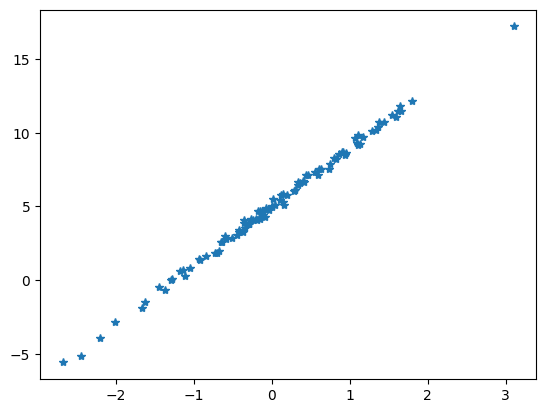

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X.detach().numpy(), y_true.detach().numpy(), '*')

In [ ]:
W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [ ]:
print(f'Initial weights = {W}')
print(f'Initial bias = {b}')

Initial weights = tensor([[-0.6973]], requires_grad=True)
Initial bias = tensor([-1.3530], requires_grad=True)


Forward pass

In [ ]:
y_hat = X @ W + b

In [ ]:
print(f'Shape of the prediction y_hat = {y_hat.shape}\n')
print(f'Prediction of the prediction y_hat = {y_hat[:10]}\n')
print(f'true labels = {y_true[:10]}\n')

Shape of the prediction y_hat = torch.Size([100, 1])

Prediction of the prediction y_hat = tensor([[-0.2232],
        [-0.9973],
        [-1.1093],
        [-1.0649],
        [-1.9542],
        [-1.1030],
        [-2.0937],
        [-2.5003],
        [-1.9237],
        [-3.5155]], grad_fn=<SliceBackward0>)

true labels = tensor([[-1.4585],
        [ 2.8282],
        [ 3.8978],
        [ 3.4259],
        [ 8.5496],
        [ 4.1059],
        [ 9.6307],
        [11.8072],
        [ 8.2450],
        [17.2208]])



Backward Pass

In [ ]:
error = y_hat - y_true
squared_error = error**2
loss = squared_error.mean()

print(f'Loss of our \'model\' = {loss}\n', loss)

Loss of our 'model' = 65.0704116821289
 tensor(65.0704, grad_fn=<MeanBackward0>)


Now we're gonna compute the derivatives of our model.

the torch.tensor.backward() function is gonna compute the gradients for us.

In [ ]:
loss.backward()

In [ ]:
print(f"Gradient for W (∂L/∂W):\n {W.grad}\n")
print(f"Gradient for b (∂L/∂b):\n {b.grad}")

Gradient for W (∂L/∂W):
 tensor([[-9.8695]])

Gradient for b (∂L/∂b):
 tensor([-13.1601])


Negative gradient = We increase the value and the loss decreases

Positive gradient = We decrease the value and the loss decreases

torch.no_grad = Context-manager that disables gradient calculation

In [ ]:
learning_rate = 0.01

epochs = 200

W = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f'Starting the training process\nStarting training params:\nW = {W.item()}\nb = {b.item()}')

for epoch in range(epochs):

  y_hat = X @ W + b
  loss = torch.mean((y_hat - y_true)**2)

  loss.backward()

  with torch.no_grad():
    W -= learning_rate * W.grad
    b -= learning_rate * b.grad

  W.grad.zero_()
  b.grad.zero_()

  if epoch % 10 == 0:
    print(f'Epoch: {epoch}\nLoss: {loss}\nW = {W.item()}\nb = {b.item()}')

print(f'Final parameters = W = {W.item()}\nb = {b.item()}')

Starting the training process
Starting training params:
W = 0.9596928954124451
b = 1.0630497932434082
Epoch: 0
Loss: 25.84319496154785
W = 1.0233412981033325
b = 1.144826889038086
Epoch: 10
Loss: 16.984769821166992
W = 1.5907717943191528
b = 1.8750228881835938
Epoch: 20
Loss: 11.16826057434082
W = 2.0497114658355713
b = 2.4673759937286377
Epoch: 30
Loss: 7.34906005859375
W = 2.4208898544311523
b = 2.947917938232422
Epoch: 40
Loss: 4.841302871704102
W = 2.7210781574249268
b = 3.337761878967285
Epoch: 50
Loss: 3.194645881652832
W = 2.9638442993164062
b = 3.65403413772583
Epoch: 60
Loss: 2.113400936126709
W = 3.1601650714874268
b = 3.9106240272521973
Epoch: 70
Loss: 1.4034122228622437
W = 3.318920373916626
b = 4.118800163269043
Epoch: 80
Loss: 0.9372038245201111
W = 3.4472920894622803
b = 4.2876996994018555
Epoch: 90
Loss: 0.631066083908081
W = 3.5510921478271484
b = 4.424737930297852
Epoch: 100
Loss: 0.43003854155540466
W = 3.635019302368164
b = 4.535926818847656
Epoch: 110
Loss: 0.29803

In [ ]:
D_in = 1
D_out = 1

linear_layer = torch.nn.Linear(in_features = D_in, out_features = D_out)

print(f"Layer's weight (W) = {linear_layer.weight}")
print(f"Layer's bias (b) = {linear_layer.bias}")

y_hat_nn = linear_layer(X)
print(f"Output of linear layer = {y_hat_nn[:10]}")

Layer's weight (W) = Parameter containing:
tensor([[0.8973]], requires_grad=True)
Layer's bias (b) = Parameter containing:
tensor([0.9821], requires_grad=True)
Output of linear layer = tensor([[-0.4717],
        [ 0.5244],
        [ 0.6685],
        [ 0.6114],
        [ 1.7556],
        [ 0.6604],
        [ 1.9351],
        [ 2.4582],
        [ 1.7164],
        [ 3.7645]], grad_fn=<SliceBackward0>)


Paarameter is a special kind of tensor that:
*  requires_grad = True by default
*  auto registers with the model
*  Handles all the bookkeeping

In [ ]:
relu = torch.nn.ReLU()
sample_data = torch.tensor([-1, -0.5, 1, 2])
activated_data = relu(sample_data)
activated_data

tensor([0., 0., 1., 2.])

In [ ]:
relu = torch.nn.GELU()
sample_data = torch.tensor([-1, -0.5, 1, 2])
activated_data = relu(sample_data)
activated_data

tensor([-0.1587, -0.1543,  0.8413,  1.9545])

Softmax -> converts output logits to a probability distribution

In [ ]:
softmax = torch.nn.Softmax(dim=1)

logits = torch.Tensor([[1, 2, 3, 4], [-1, -2, 2, 1]])
probs = softmax(logits)

print(f"Output probs: {probs}")
print(f"Sum of logits = {probs[0].sum()}")

Output propas: tensor([[0.0321, 0.0871, 0.2369, 0.6439],
        [0.0347, 0.0128, 0.6964, 0.2562]])
Sum of logits = 1.0


In [ ]:
vocab_size = 10
embedding_dim = 5

embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

input_ids = torch.tensor([[1, 5, 0, 8]])
word_vectors = embedding_layer(input_ids)
print(word_vectors)

tensor([[[-0.4402,  0.0799, -0.6400,  2.1533, -0.5523],
         [ 0.8463, -3.5859, -0.5190,  0.1620,  0.4802],
         [-0.0546,  1.1192, -1.5931,  1.3073, -0.2659],
         [-0.0382, -0.0347, -1.2555,  0.5908, -1.0602]]],
       grad_fn=<EmbeddingBackward0>)


nn.layernorm - rescales everything to a stable range

In [ ]:
norm_layer = torch.nn.LayerNorm(normalized_shape=5)
input_features = torch.tensor([[[1.0, 2.0, 3.0, 4.0, 5.0], [4.0, 5.0, 6.0, 7.0, 8.0]]])
normalized_features = norm_layer(input_features)

In [ ]:
print(f"Mean of normalized features = {normalized_features.mean(dim=-1)}")
print(f"Std of normalized features = {normalized_features.std(dim=-1)}")

Mean of normalized features = tensor([[0., 0.]], grad_fn=<MeanBackward1>)
Std of normalized features = tensor([[1.1180, 1.1180]], grad_fn=<StdBackward0>)


nn.dropout - randomly zeros out part of the neurons. Forces the network to utilize all of its neurons, and not rely only on a few strong ones

In [ ]:
dropout_layer = torch.nn.Dropout(p=0.5)
input_tensor = torch.ones(1, 10)

dropout_layer.train()
output_during_training = dropout_layer(input_tensor)

dropout_layer.eval()
output_during_inference = dropout_layer(input_tensor)

print(f"Dropout output during training = {output_during_training}")
print(f"Dropout output during inference / eval = {output_during_inference}")

Dropout output during training = tensor([[0., 0., 2., 0., 2., 2., 2., 0., 0., 0.]])
Dropout output during inference / eval = tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


nn.Module - organizes the module


tortch.Optim - optimizer, knows how to adjust the layers

In [ ]:
class LinRegModel(torch.nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()
    self.linear_layer = torch.nn.Linear(in_features, out_features)

  def forward(self, x):
    return self.linear_layer(x)

model = LinRegModel(in_features=1, out_features=1)

In [ ]:
print(model)

LinRegModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
learning_rate = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = torch.optim.Muon

loss_fn = torch.nn.MSELoss()

Essential 3 lines, the trainign process

In [ ]:
epochs = 500

for epoch in range(epochs):
  y_hat = model(X)

  loss = loss_fn(y_hat, y_true)

  # Zero the gradients
  optimizer.zero_grad()
  # Compute gradinets
  loss.backward()
  # update the parameters
  optimizer.step()

  if epoch % 10 == 0:
    print(f"Epoch {epoch} Loss = {loss.item()}")

Epoch 0 Loss = 43.121944427490234
Epoch 10 Loss = 41.26885223388672
Epoch 20 Loss = 39.46440505981445
Epoch 30 Loss = 37.71355438232422
Epoch 40 Loss = 36.01912307739258
Epoch 50 Loss = 34.38216018676758
Epoch 60 Loss = 32.802547454833984
Epoch 70 Loss = 31.279556274414062
Epoch 80 Loss = 29.81212615966797
Epoch 90 Loss = 28.399063110351562
Epoch 100 Loss = 27.039113998413086
Epoch 110 Loss = 25.731006622314453
Epoch 120 Loss = 24.473466873168945
Epoch 130 Loss = 23.265207290649414
Epoch 140 Loss = 22.104955673217773
Epoch 150 Loss = 20.991445541381836
Epoch 160 Loss = 19.92340660095215
Epoch 170 Loss = 18.89958381652832
Epoch 180 Loss = 17.918725967407227
Epoch 190 Loss = 16.979595184326172
Epoch 200 Loss = 16.08095359802246
Epoch 210 Loss = 15.221582412719727
Epoch 220 Loss = 14.40027141571045
Epoch 230 Loss = 13.615819931030273
Epoch 240 Loss = 12.867039680480957
Epoch 250 Loss = 12.152765274047852
Epoch 260 Loss = 11.471827507019043
Epoch 270 Loss = 10.823089599609375
Epoch 280 Los

torch.nn module

no one bulds moder, from the ground up anymore, pure math style, like we just did (unless you're working at some hardcore big tech research lab, but we're not building for edgecases here). If you're not using something pretrained to finetune it to you taks, you'll most likely be using pre build layers, like lego blocks, and building your thing out of them.

And tha's what torch.nn is, a liblary of prebuild layers, that forms the backbone of 99.9% professional pytorch models. Something like keras for teensorflow (remember theese days, you can choose what backend keras uses, be it tf, torch or jax).

First of all, the most importanbt layer.

torch.nn.linear, the workhorse of every single ANN, it does exactly what our $x @ w + b$ did.

Using torch.nn.linear:

In [ ]:
# Initialize inpur and ourput dims
D_in, D_out = 1, 1

linear_layer = torch.nn.Linear(in_features=D_in, out_features=D_out)

# Let's look at the randomly initalized params, notice the requires_grad=True. The layers are trainable out of the box
print(f'Linear layer weights : {linear_layer.weight}\nLinear layer bias = :{linear_layer.bias}')

# and now the output, essentially the 'forward pass'
y_hat_linear = linear_layer(X[:10])
print(f'Output of the linear layer: {y_hat_linear}')

Linear layer weights : Parameter containing:
tensor([[-0.1811]], requires_grad=True)
Linear layer bias = :Parameter containing:
tensor([-0.4521], requires_grad=True)
Output of the linear layer: tensor([[-0.1586],
        [-0.3597],
        [-0.3888],
        [-0.3772],
        [-0.6082],
        [-0.3871],
        [-0.6444],
        [-0.7500],
        [-0.6003],
        [-1.0137]], grad_fn=<AddmmBackward0>)


Notice that when we print out the shapes we get 'Parameter containing', but what is a parameter again?

In pytroch it's special tensor that:
1.  Has requires_grad=True by default
2.  Auto registeres with the model
3.  Handles all the bookkeeping, like graph exe for us

Not they're limiting factor is that stacking many linear layers on top of eachother, is just the same as a single larger linear layer. They are only able to for a line. So, as you can recall form our previous lessons, we're gonna need some nonlinear function to activate them. In pytroch we introduce them BETWEEN the linear layers.

Let's start with the simple `nn.ReLU`. It's as simple as it gets, $ReLU(x) = max(0, x)$. It introduces non-linearity by simply zeroing out negative values, which helps the network learn complex patterns without succumbing to the vanishing gradient problem as easily as older functions like Sigmoid.



In [ ]:
import matplotlib.pyplot as plt
import torch

x = torch.linspace(-5, 5, 100)
relu = torch.nn.ReLU()
y = relu(x)

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y.numpy(), label='ReLU(x) = max(0, x)', color='b', linewidth=2)
plt.axvline(0, color='black', linewidth=1)
plt.axhline(0, color='black', linewidth=1)
plt.title('ReLU Activation Function')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
relu = torch.nn.ReLU()
dummy_data = torch.tensor([-1, -2, 0, 1, 2, 3], dtype = torch.float)
activated_data = relu(dummy_data)
print(f'Data b4 activation : {dummy_data}\nData after activation: {activated_data}')

Data b4 activation : tensor([-1., -2.,  0.,  1.,  2.,  3.])
Data after activation: tensor([0., 0., 0., 1., 2., 3.])


But the current industry standard for transformers is the GELU, Gaussian Error Linear unit, $GELU(x) = x \Phi(x) = x \cdot \frac{1}{2} \left[ 1 + \text{erf} \left( \frac{x}{\sqrt{2}} \right) \right] $

In [ ]:
gelu = torch.nn.GELU()
dummy_data = torch.tensor([-1, -2, 0, 1, 2, 3], dtype = torch.float)
activated_data = gelu(dummy_data)
print(f'Data b4 activation : {dummy_data}\nData after activation: {activated_data}')

Data b4 activation : tensor([-1., -2.,  0.,  1.,  2.,  3.])
Data after activation: tensor([-0.1587, -0.0455,  0.0000,  0.8413,  1.9545,  2.9960])


nn.softmax

A very important layer, usually used in the last layer of a classification network (not regression). It's function is to transform the models raw outputs, called logits, into confidence scores, or probability scores, a probability dist., so the logits are not in range of <0, 1> and add up to 1.

As in the models is 30% ceertain that the outpus is a dog, and 70% sure the ourput is a cat.

Here is a simple example of how 5 random logit outputs are transformed into probabilities by Softmax ($e^{logit} / \sum e^{logit}$):

| Class | Logit ($x$) | Exponential ($e^x$) | Probability ($e^x / \sum e^x$) |
| :--- | :--- | :--- | :--- |
| **Dog** | 2.5 | $e^{2.5} \approx 12.18$ | $12.18 / 15.63 \approx$ **77.9%** |
| **Cat** | 1.0 | $e^{1.0} \approx 2.71$ | $2.71 / 15.63 \approx$ **17.3%** |
| **Bird**| -0.5 | $e^{-0.5} \approx 0.60$ | $0.60 / 15.63 \approx$ **3.8%** |
| **Fish**| -2.0 | $e^{-2.0} \approx 0.13$ | $0.13 / 15.63 \approx$ **0.8%** |
| **Frog**| -4.0 | $e^{-4.0} \approx 0.01$ | $0.01 / 15.63 \approx$ **0.1%** |
| **SUM** | N/A | $\sum e^x \approx 15.63$ | **100%** |


In [ ]:
softmax = torch.nn.Softmax(dim=1)
logits = torch.tensor([[1,0.9,-0.5,0.5], [1,-0.5,0.7,-0.2]], dtype=torch.float)
probabilities = softmax(logits)

print(f'Logits = {logits}\nLogits after softmax = {probabilities}\nProbabilities sum = {probabilities[0].sum()}')

Logits = tensor([[ 1.0000,  0.9000, -0.5000,  0.5000],
        [ 1.0000, -0.5000,  0.7000, -0.2000]])
Logits after softmax = tensor([[0.3657, 0.3309, 0.0816, 0.2218],
        [0.4415, 0.0985, 0.3271, 0.1330]])
Probabilities sum = 1.0


Now for the LLM special. These layers are the backbone of all the modern LLMs

1. No.1 nn.Embedding- transforms words into numbers. We'll see how it works under the hood next time (we're gonna be building it from scratch), for now that's all you need to know. Essentially a giant lookup table.

In [ ]:
vocab_size = 20 # madol know 20 unique words
embedding_dim = 4 # eacvh word is represented as a 4D vector

embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

# esssentially a sentence where each word is a number. Normally to get that we'd use tokenization, but more on that next time
input_ids = torch.tensor([[1, 3, 5, 6, 8]])
word_vectors = embedding_layer(input_ids)

print(f'Input token ids = {input_ids}\nOutput word vectors={word_vectors}')

Input token ids = tensor([[1, 3, 5, 6, 8]])
Output word vectors=tensor([[[-0.8169, -0.0684,  0.0565,  0.6553],
         [-0.8490, -1.5130,  0.2355, -0.0992],
         [-0.2989, -0.8521, -0.4587,  0.6375],
         [ 0.0201,  0.6926,  0.9072, -0.9151],
         [-1.4167,  1.2443, -0.7659, -0.0653]]], grad_fn=<EmbeddingBackward0>)


nn.layernorm

prevents gradient vanishing and explosion. The deeper the network the more likely it is form some of the gradinets to completely disappear and some to explode. We dont want that, so we use layernorm to normalize them, fit them into a static, stable range

In [ ]:
norm_layer = torch.nn.LayerNorm(normalized_shape=embedding_dim, elementwise_affine=False)
input_features = torch.tensor([[1, 2, 3, 4], [4, 5, 6, 7]], dtype=torch.float)
normalized_features = norm_layer(input_features)

print(f'input_features = {input_features}\nnormalized_features = {normalized_features}')
print(f'mean of the vector = {normalized_features.mean(dim=-1)}\nStandard deviation = {normalized_features.std(dim=-1, correction=0)}')

input_features = tensor([[1., 2., 3., 4.],
        [4., 5., 6., 7.]])
normalized_features = tensor([[-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416]])
mean of the vector = tensor([0., 0.])
Standard deviation = tensor([1.0000, 1.0000])


nn.dropout

the standard dropout layer. Randomly zeros neurons during training, and only during training. It just applies a mask of 0 and 0 during training, and during inference the mask is just 1s.

In [ ]:
dropout_layer = torch.nn.Dropout(p=0.5)
input_layer = torch.ones(1, 10)

# activating the dropout for training
dropout_layer.train()
output_during_training = dropout_layer(input_layer)

# deactivationg during inference
dropout_layer.eval()
output_during_eval = dropout_layer(input_layer)

print(f'output of the dropout during training: {output_during_training}')
print(f'output of the dropout during training: {output_during_inference}')

output of the dropout during training: tensor([[2., 0., 0., 2., 2., 0., 0., 2., 2., 2.]])
output of the dropout during training: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


parameter updates are also done in an easier and cleaner way.

that's the job of torch.optim.

so in essence:
*    torch.nn.Module - cleans up model construction
*    torch.nn.optim - cleans up the learning process

we're gonna be building our real module now, so here's how it usually goes:

1. Create your network as a class that inherits from torch.nn.Module
2. Define it's layers in the constructor
3. Connect them in the forward method. Define the dataflow inside the network

In [ ]:
class LinRegModel(torch.nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()
    # here we define all the layers we're gonna use
    self.linear_layer = torch.nn.Linear(in_features, out_features)

  def forward(self, x):
    # here we connect them all, we tell how the data flows thrugh them
    return self.linear_layer(x)

model = LinRegModel(in_features=1, out_features=1)
print(f'Model architecture = \n{model}')

Model architecture = 
LinRegModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


torch.optim

contains all the optimizers you're gonna need. It's job is updating all the weight, according to it's own regime. We're gonna use adam, since it's good enough for almost everything, but there are other options, most notably Muon.

### Understanding Optimizers: Adam and Muon

**Adam (Adaptive Moment Estimation):**
Adam is the industry standard optimizer for most deep learning tasks. It computes adaptive learning rates for each parameter. Instead of just directly subtracting the gradient from the weights, Adam keeps track of two moving averages (moments):
1.  **First Moment (Mean):** A moving average of past gradients (momentum). This helps push the optimizer in the right direction, smoothing out the updates and crossing local ravines.
2.  **Second Moment (Variance):** A moving average of past *squared* gradients. This scales the learning rate down for parameters that experience highly variable, massive gradients, and un-scales it for parameters with small updates.

**Advantages of Adam:** It often converges much faster than standard Stochastic Gradient Descent (SGD) and requires far less hyperparameter tuning for the learning rate.

**Muon:**
Muon is a newer, highly specialized optimizer designed to improve convergence on specific large-scale tasks (like training massive Transformers). While Adam uses standard element-wise momentum, Muon leverages Newton-like momentum or orthogonal updates, allowing it to navigate the complex, high-dimensional curvature of massive neural networks more efficiently. It can dramatically speed up training in large language models compared to standard AdamW.


In [ ]:
import torch.optim as optim

learning_rate = 0.01

# we pass the model.parameters() to tell the the optimizer which parameters it should manage
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_fn = torch.nn.MSELoss()

Now for the most important part, the training loop. it essentially boils down to 3 fucntions:

1. optimizer.zero_grad() - zeros the gradients
2. loss.backward() - computes the gradients
3. optimizer.step() - updates all the parameters according to the gradients

In [ ]:
epochs = 100

for epoch in range(epochs):

  y_hat = model(X)

  # calculate the loss
  loss = loss_fn(y_hat, y_true)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    w_learned = model.linear_layer.weight.item()
    b_learned = model.linear_layer.bias.item()
    print(f"Epoch {epoch:02d}: Loss={loss.item():.4f}, W={w_learned:.3f}, b={b_learned:.3f}")


Epoch 00: Loss=32.8900, W=0.719, b=0.462
Epoch 10: Loss=31.2781, W=0.819, b=0.562
Epoch 20: Loss=29.7147, W=0.918, b=0.661
Epoch 30: Loss=28.2049, W=1.016, b=0.760
Epoch 40: Loss=26.7512, W=1.113, b=0.858
Epoch 50: Loss=25.3545, W=1.209, b=0.954
Epoch 60: Loss=24.0146, W=1.303, b=1.050
Epoch 70: Loss=22.7305, W=1.395, b=1.144
Epoch 80: Loss=21.5009, W=1.486, b=1.238
Epoch 90: Loss=20.3245, W=1.575, b=1.330
